# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [4]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.metrics import f1_score

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [6]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [7]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [8]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

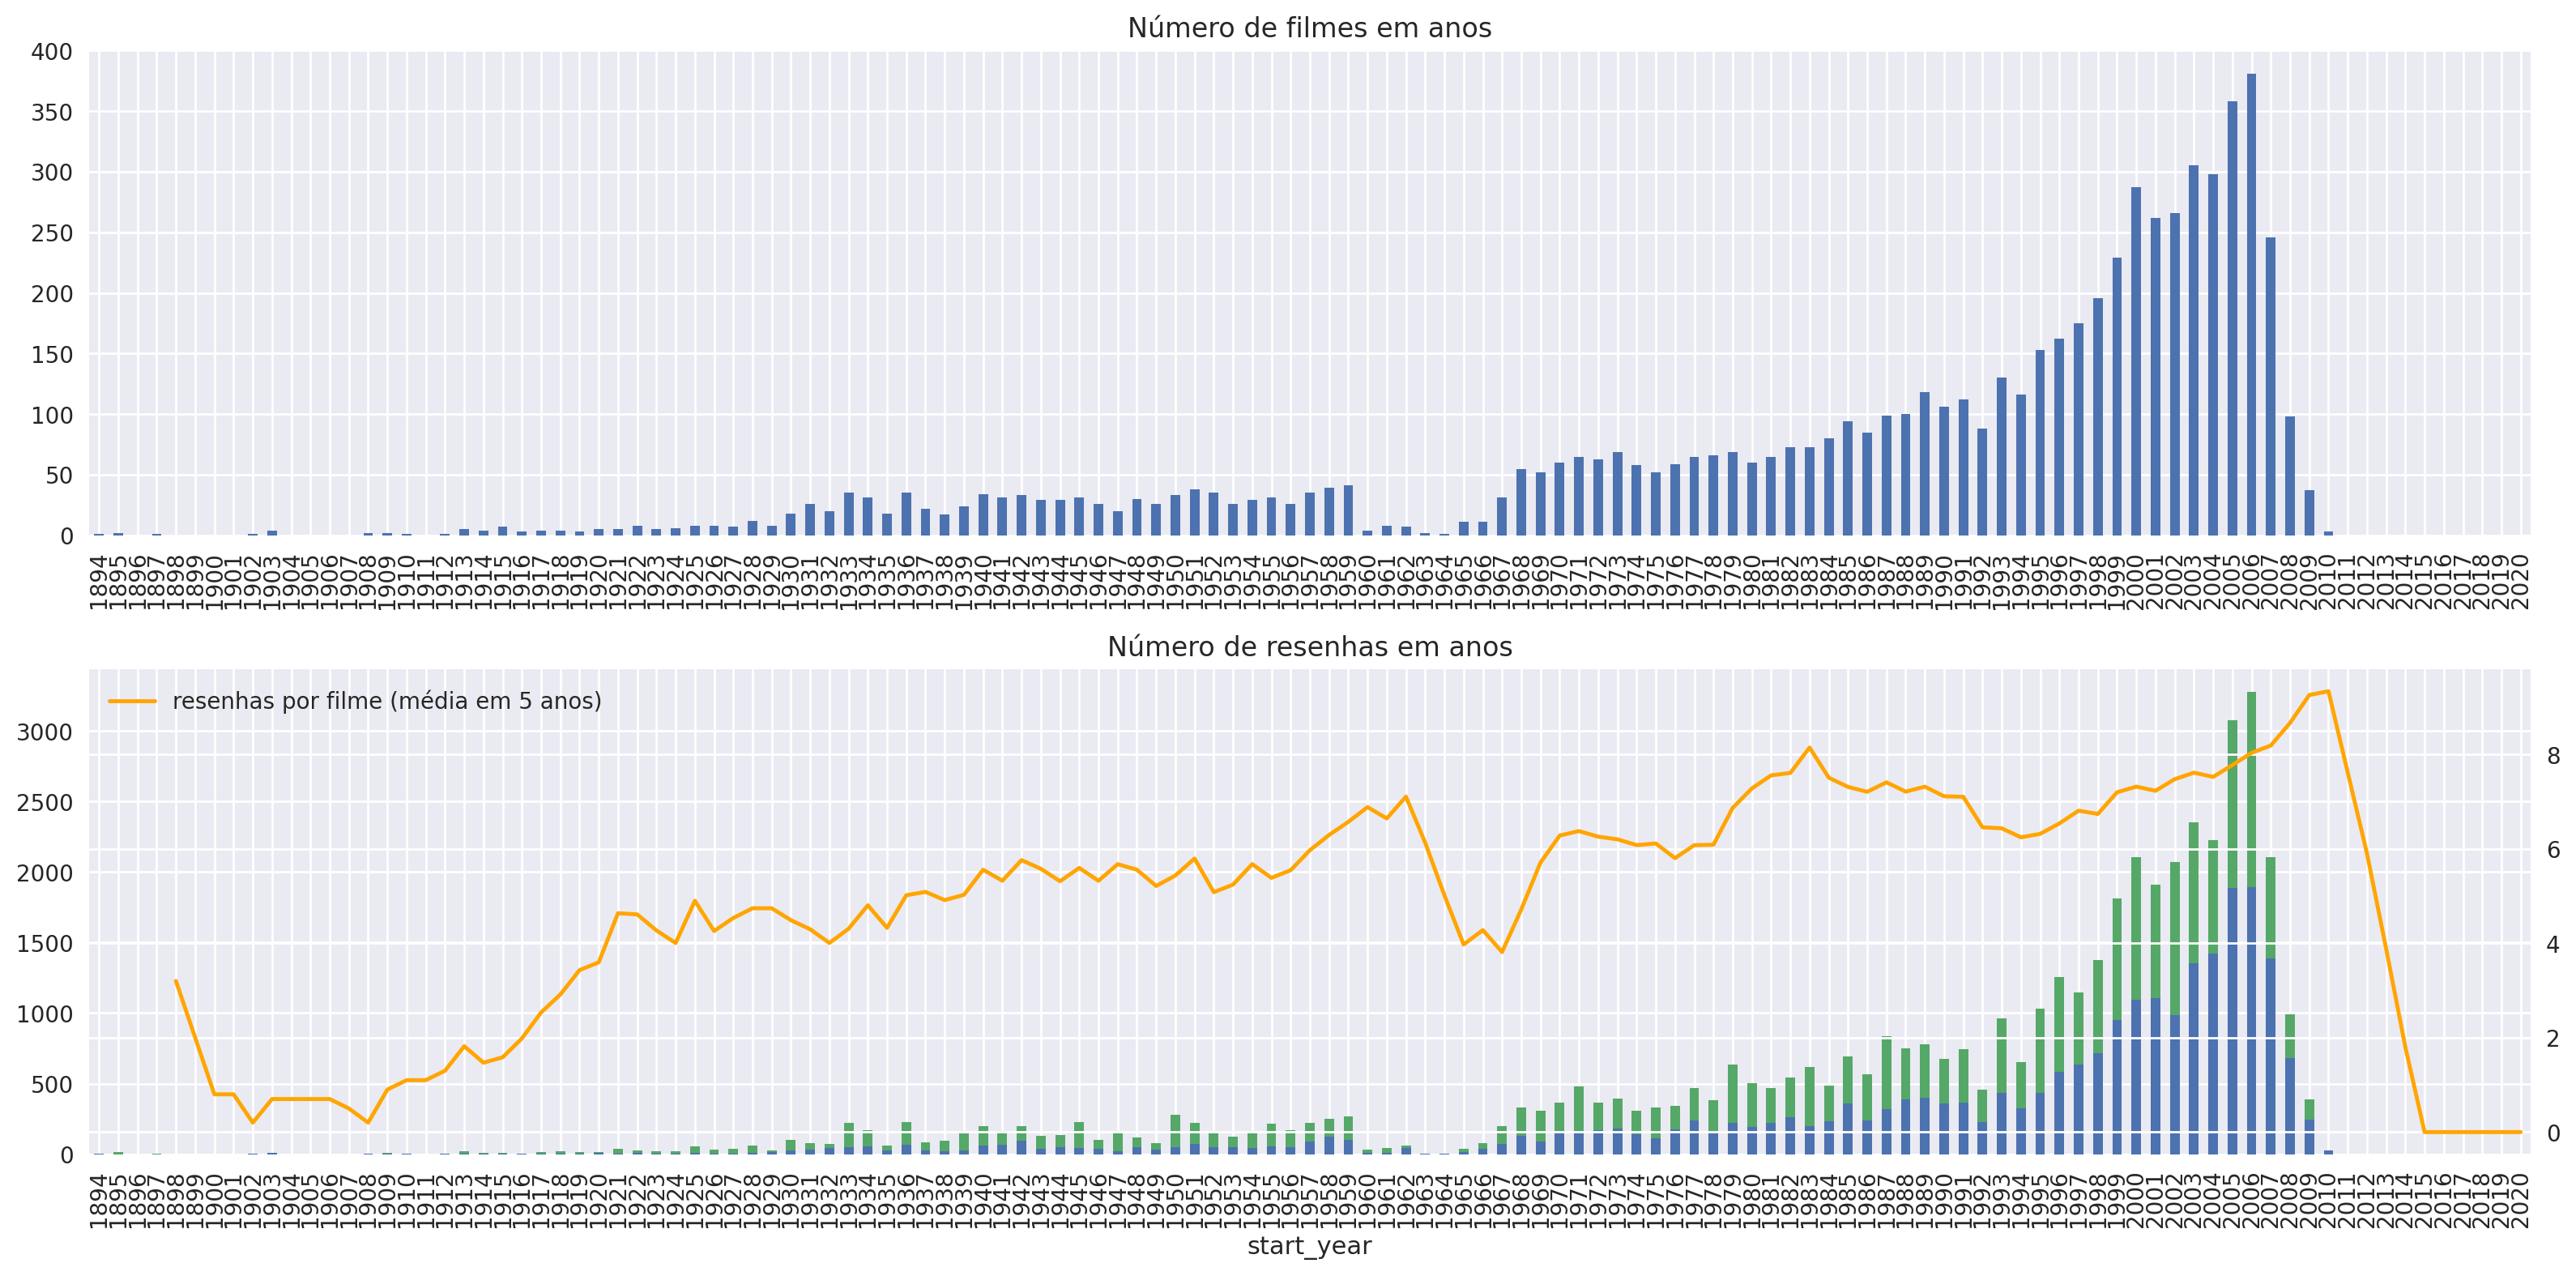

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

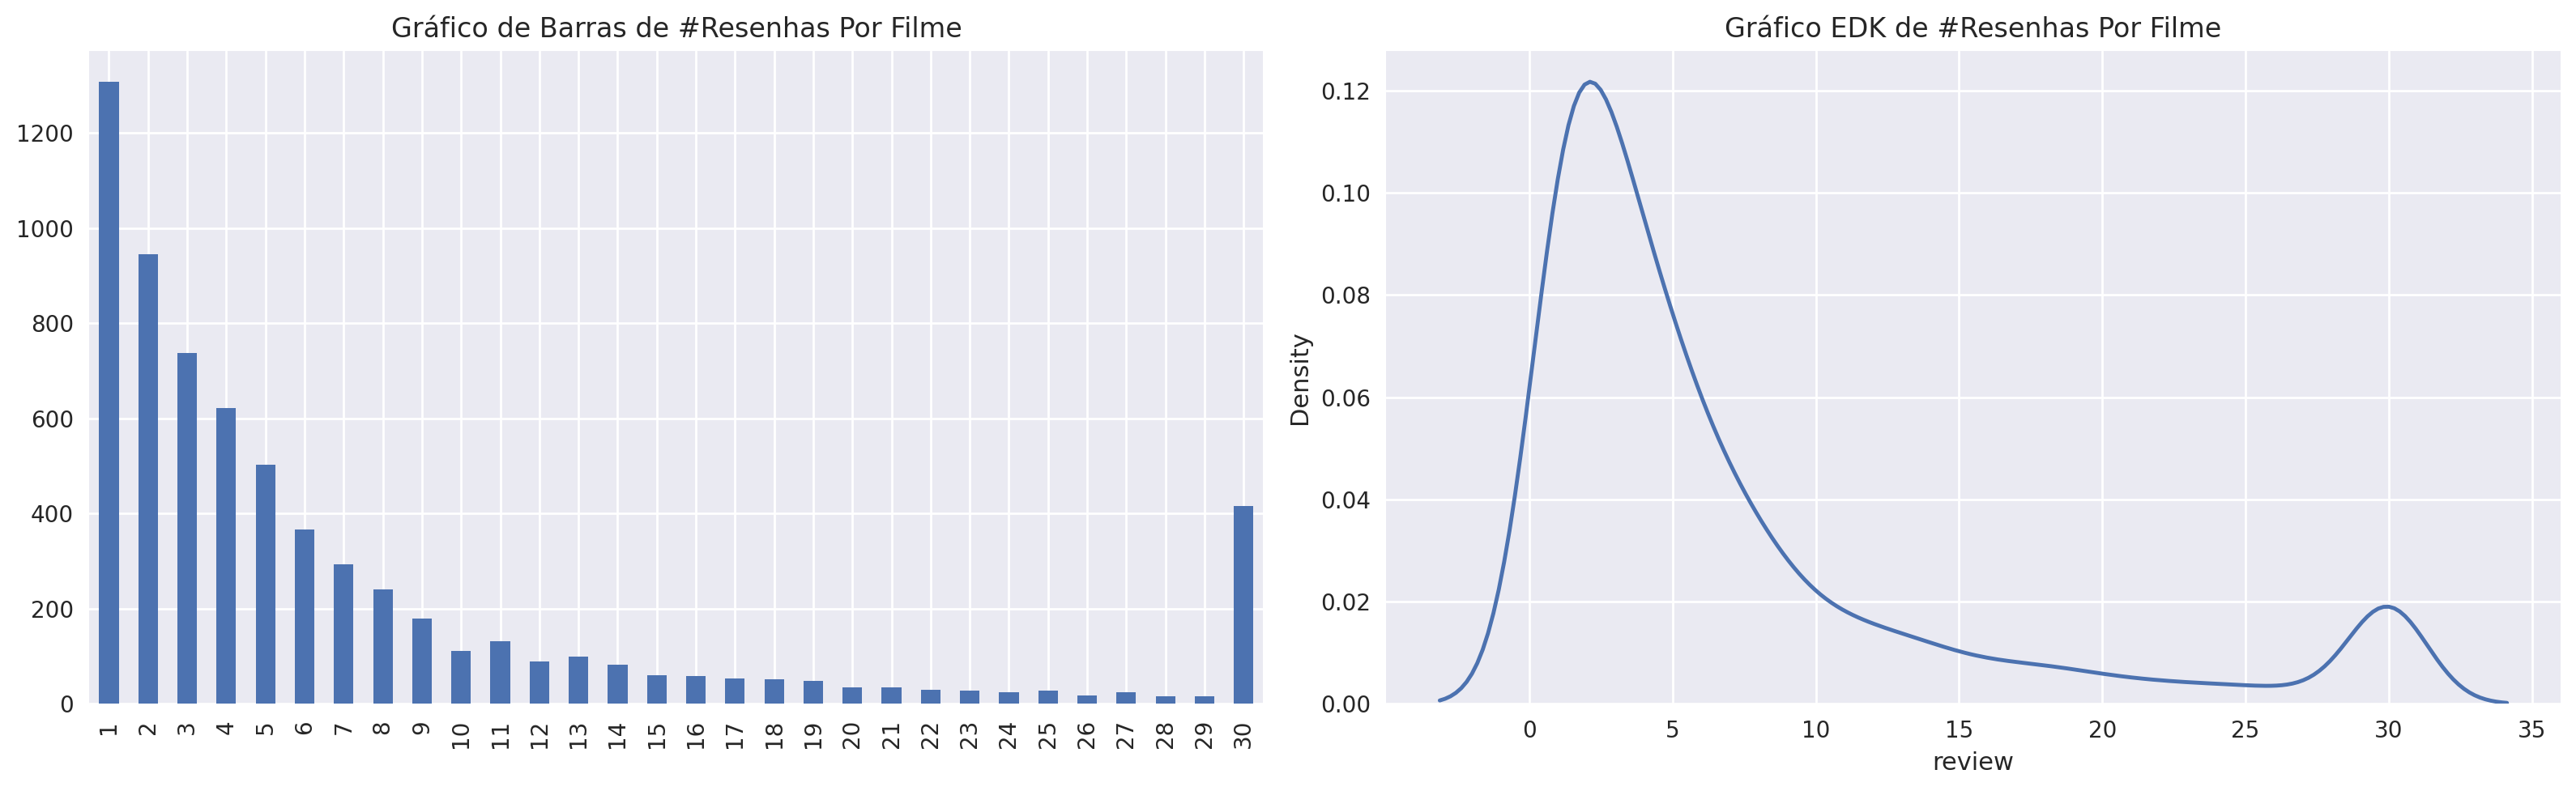

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

In [8]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

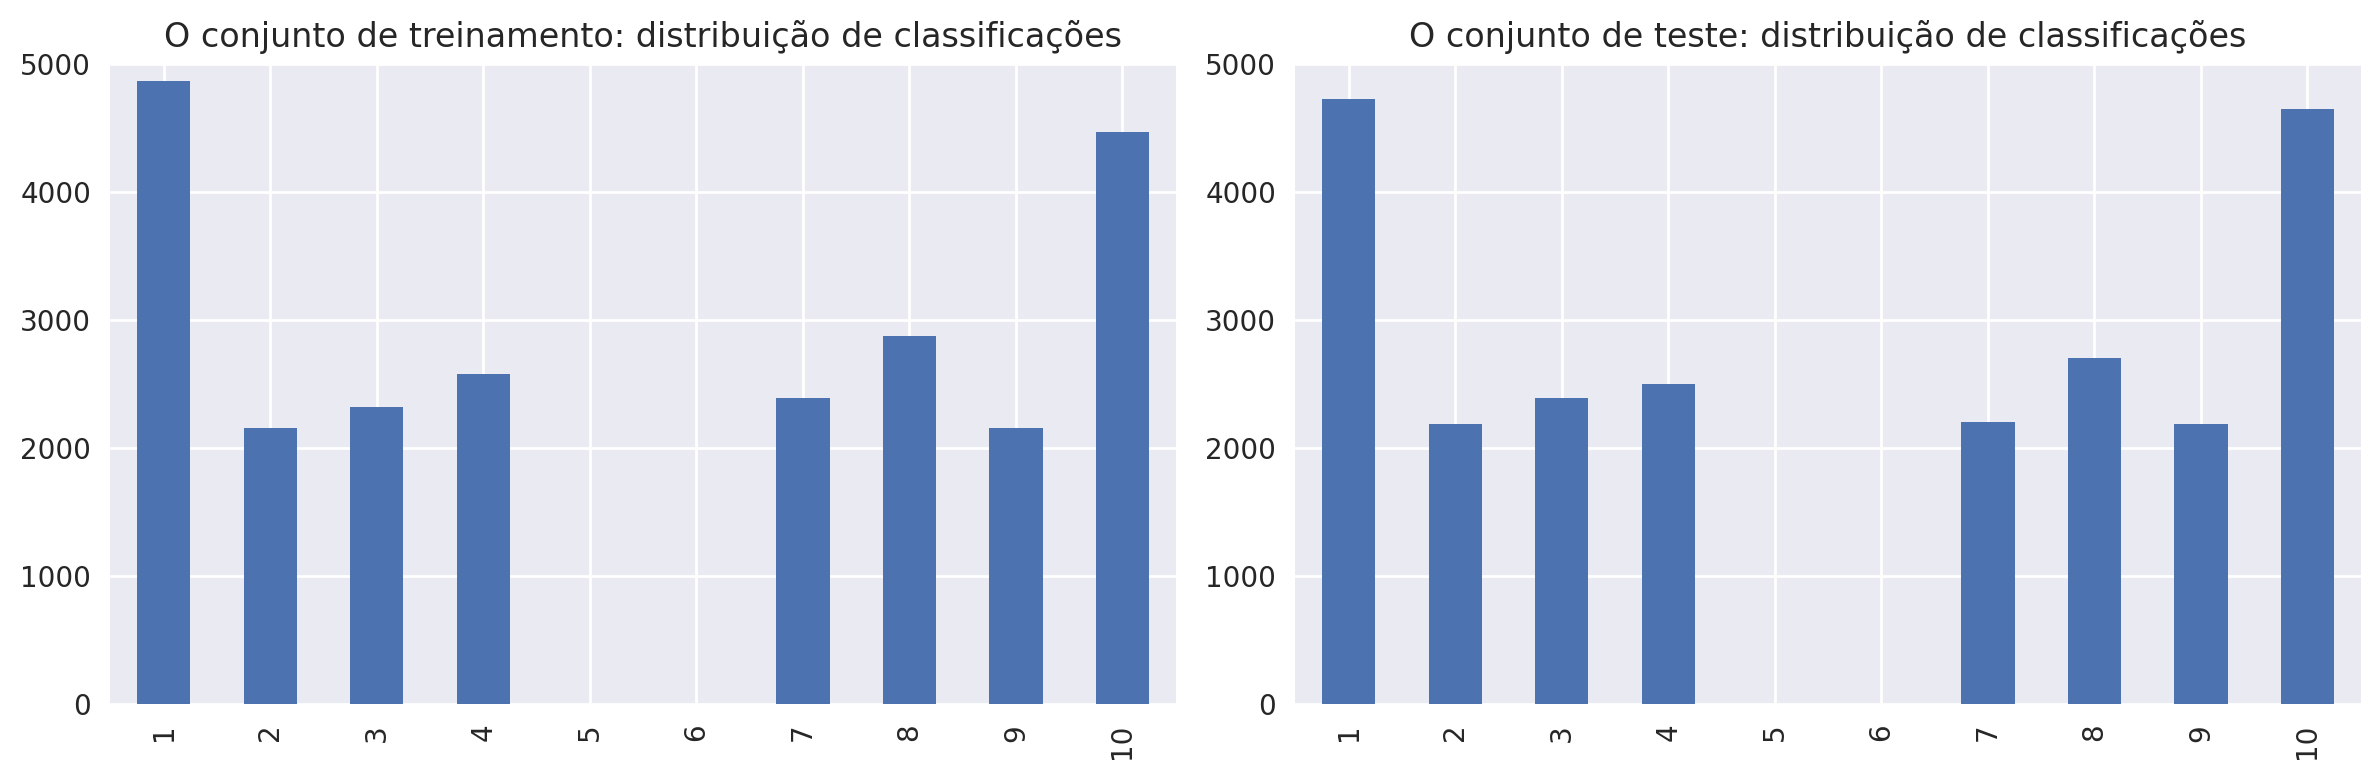

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


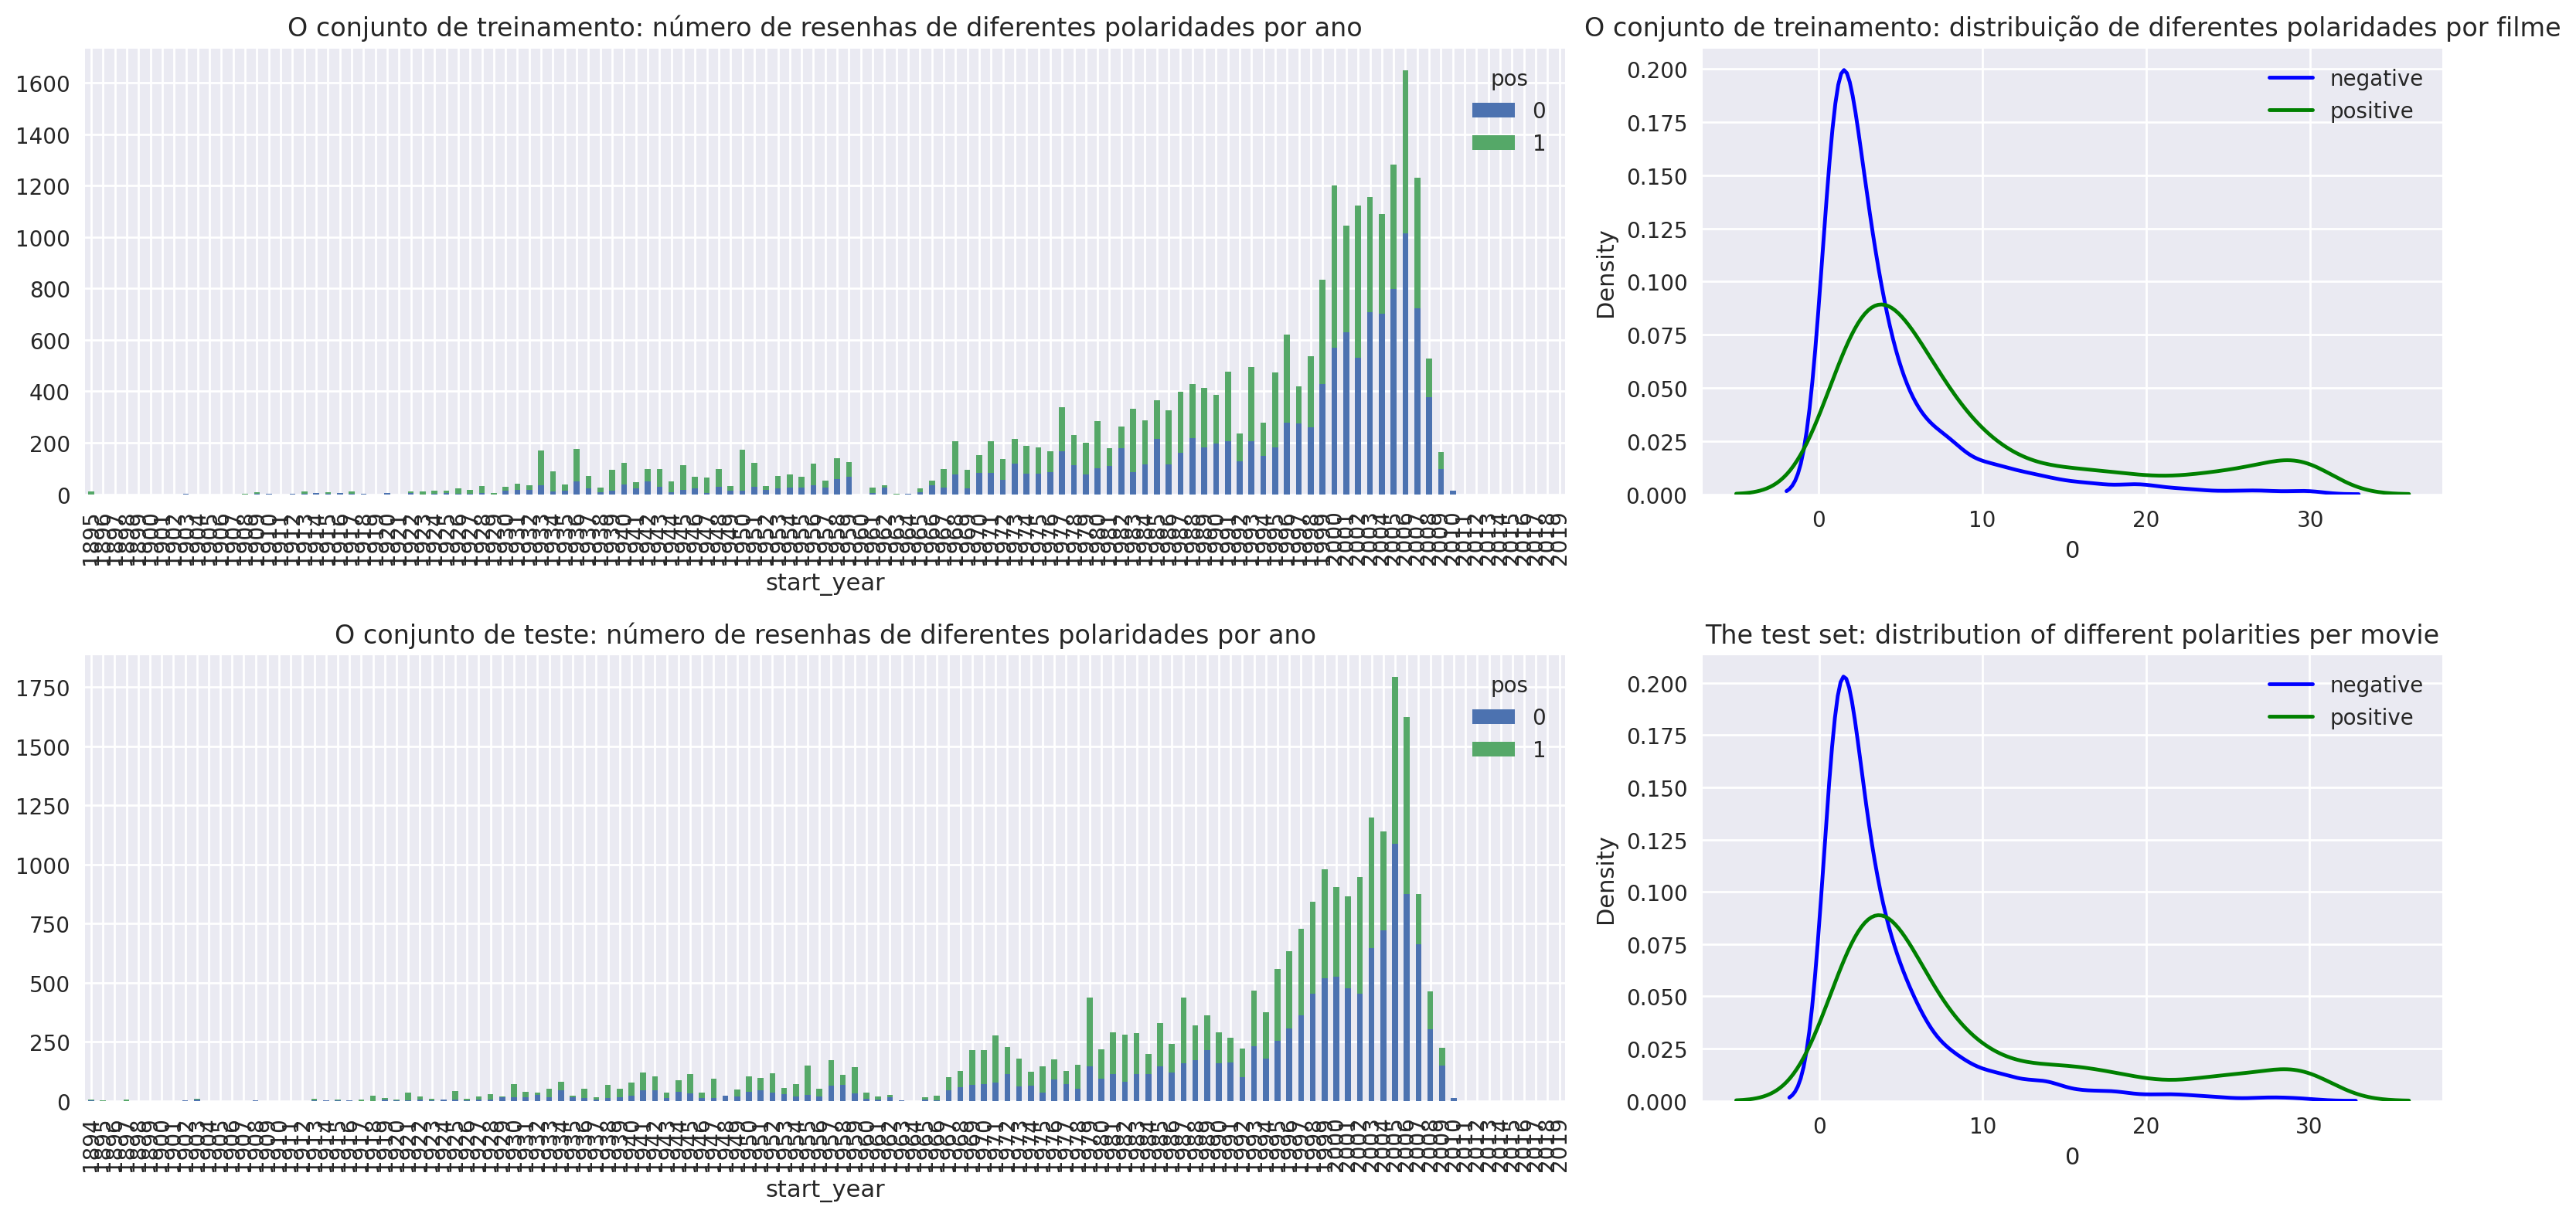

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [20]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)

        max_f1_score = max(f1_scores)
        eval_stats[type]['F1'] = max_f1_score
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [9]:
df_reviews['review_norm'] = df_reviews['review'].str.lower()  # letras minúsculas
df_reviews['review_norm'] = df_reviews['review_norm'].str.replace(r'[^a-z\s]', '', regex=True)  # remove tudo que não for letra ou espaço
df_reviews['review_norm'] = df_reviews['review_norm'].str.strip()  # remove espaços extras no começo/fim

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [10]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

In [11]:
from sklearn.dummy import DummyClassifier

In [12]:
# features (texto bruto por enquanto)
X_train = df_reviews_train['review']
X_test = df_reviews_test['review']

y_train = train_target
y_test = test_target

In [29]:
# modelo baseline com estratégia de previsões aleatórias respeitando distribuição
dummy_clf = DummyClassifier(strategy='stratified', random_state=12345)

# treino
dummy_clf.fit(X_train, y_train)

DummyClassifier(random_state=12345, strategy='stratified')

          train  test
Accuracy   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50


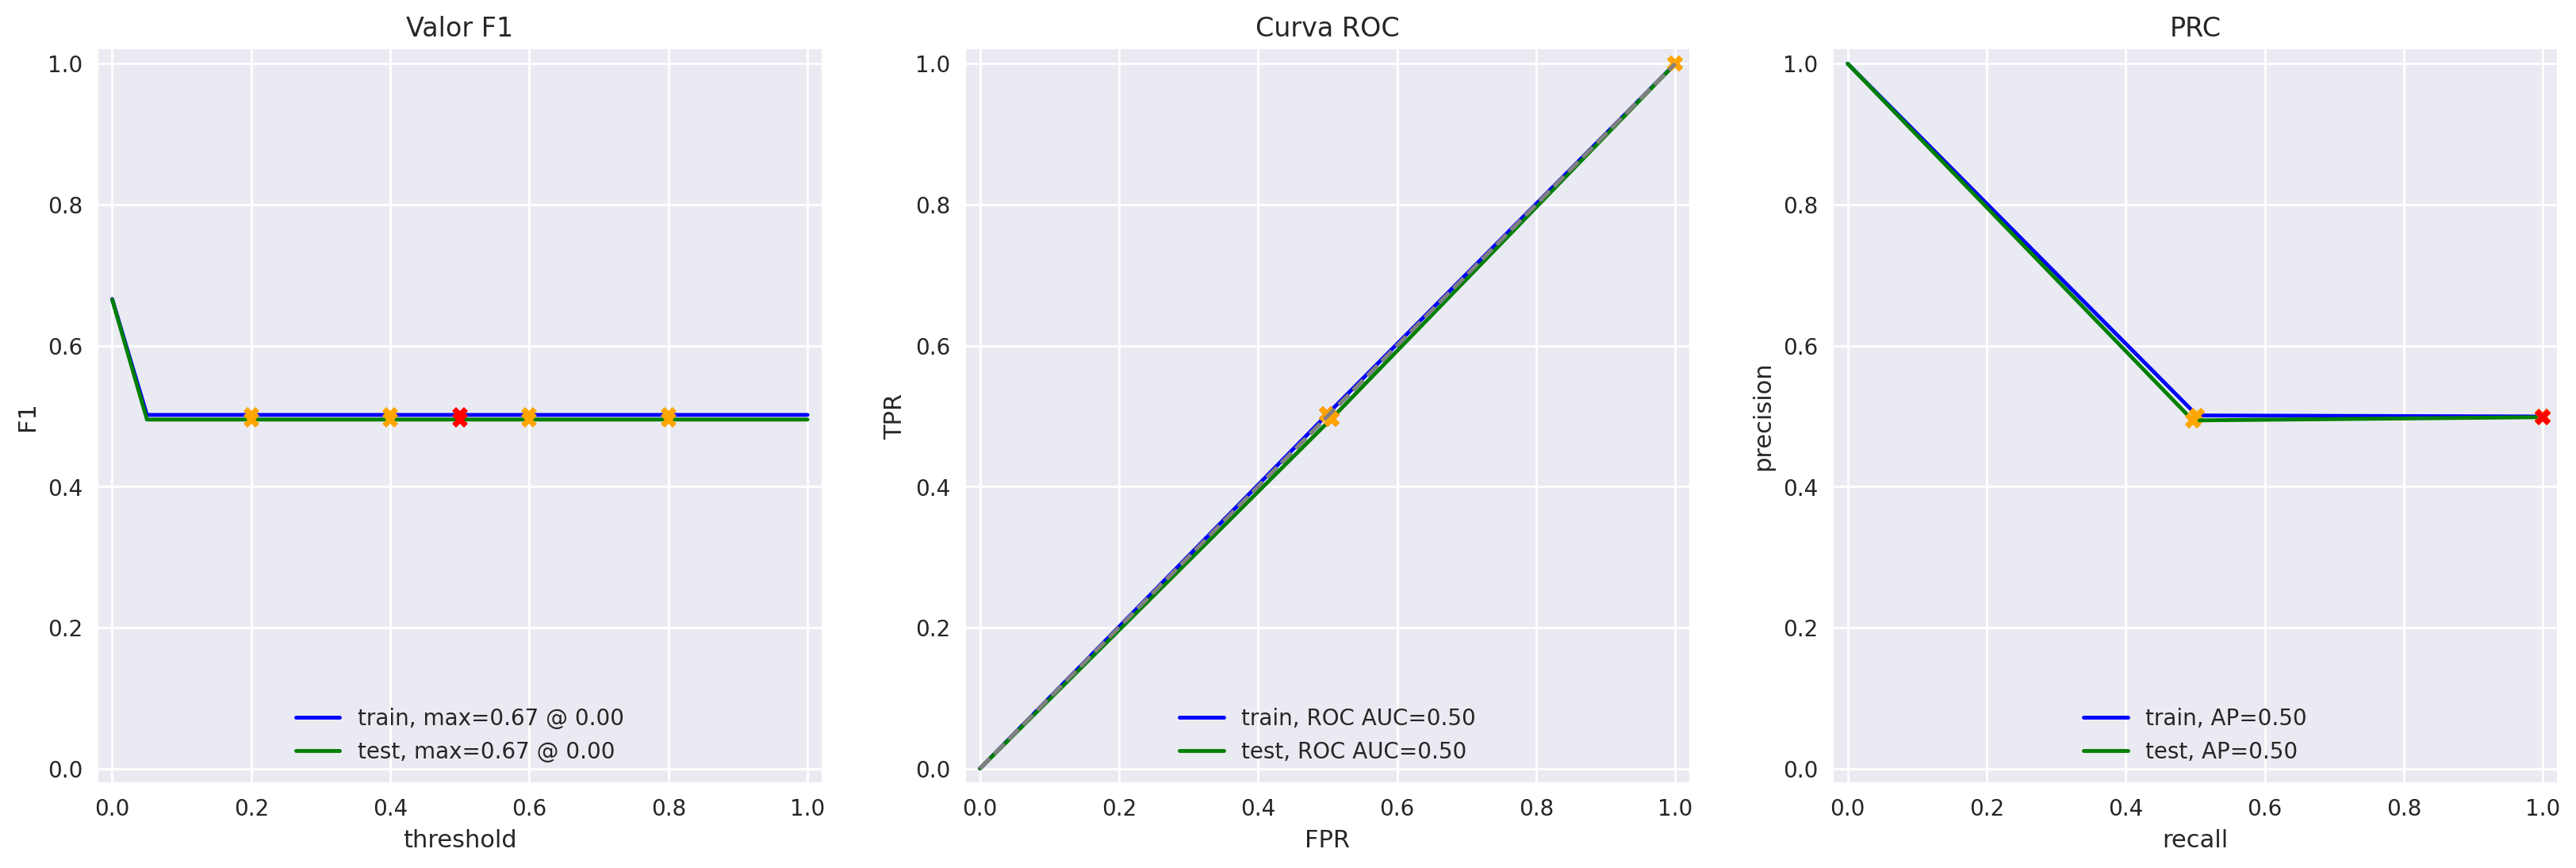

In [31]:
evaluate_model(dummy_clf, X_train, y_train, X_test, y_test)

Como esperado para um modelo de referência sem aprendizado real, as métricas refletem desempenho próximo ao acaso: Acurácia e ROC AUC em torno de 0,50, indicando que o modelo não consegue discriminar entre classes. __O valor de F1 mais elevado, próximo a 0,67, ocorre devido à distribuição das classes e à forma como o DummyClassifier realiza a amostragem estratificada, mas não representa capacidade preditiva significativa.__ Esse modelo serve como baseline para comparar o ganho real dos modelos baseados em aprendizado.

### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [14]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [27]:
# stopwords
stop_words = stopwords.words('english')

# vetorizar texto
tfidf = TfidfVectorizer(
    stop_words=stop_words,
    max_features=10000,
    ngram_range=(1, 2)  # unigrams + bigrams (melhora bastante o F1)
)

# transformar dados
train_features_1 = tfidf.fit_transform(df_reviews_train['review'])
test_features_1 = tfidf.transform(df_reviews_test['review'])

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

# modelo
model_1 = LogisticRegression(max_iter=1000, random_state=12345)

# treino
model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

          train  test
Accuracy   0.93  0.89
F1         0.93  0.89
APS        0.98  0.95
ROC AUC    0.98  0.96


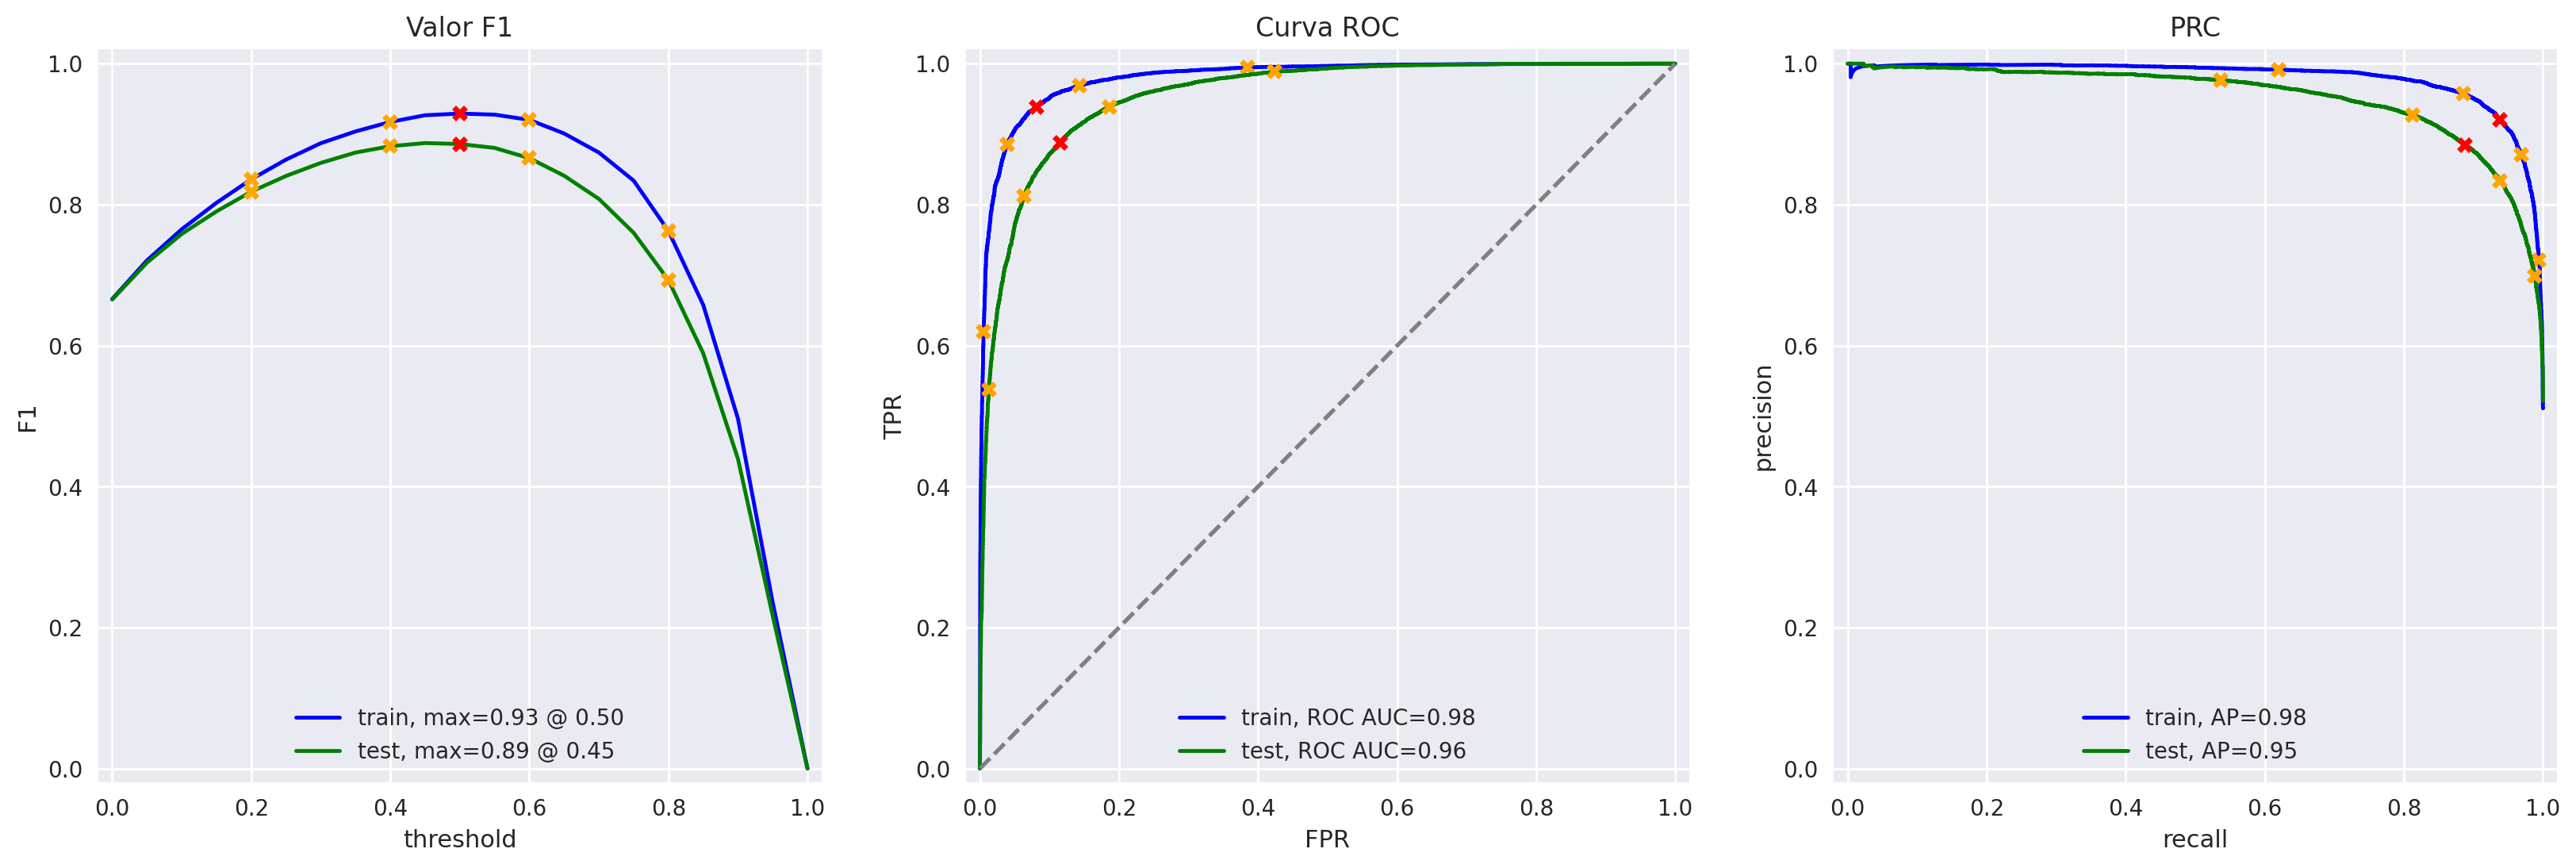

In [28]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

__O modelo 1 apresentou um desempenho robusto, atingindo um F1-score de 0,89 no conjunto de teste, alinhado ao requisito mínimo do projeto__. As métricas de Acurácia, APS e ROC AUC indicam boa capacidade preditiva e generalização consistente entre os conjuntos de treino e teste. As curvas de avaliação demonstram que o modelo mantém um equilíbrio adequado entre precisão e recall, sugerindo que a abordagem simples de TF-IDF com regressão logística já é eficaz para a tarefa, mesmo sem pré-processamento linguístico avançado.

### Modelo 2 - spaCy, TF-IDF e Regressão Linear

In [23]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [24]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [25]:
# pré-processar textos
df_reviews_train['review_lem'] = df_reviews_train['review'].progress_apply(text_preprocessing_3)
df_reviews_test['review_lem'] = df_reviews_test['review'].progress_apply(text_preprocessing_3)

# TF-IDF vectorizer (com stopwords removidas e bigramas)
tfidf_2 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

# transformar texto em features
train_features_2 = tfidf_2.fit_transform(df_reviews_train['review_lem'])
test_features_2 = tfidf_2.transform(df_reviews_test['review_lem'])

# target
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

# modelo
model_2 = LogisticRegression(max_iter=1000, random_state=12345)

# treinar
model_2.fit(train_features_2, train_target)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

LogisticRegression(max_iter=1000, random_state=12345)

          train  test
Accuracy   0.92  0.89
F1         0.92  0.89
APS        0.98  0.96
ROC AUC    0.98  0.96


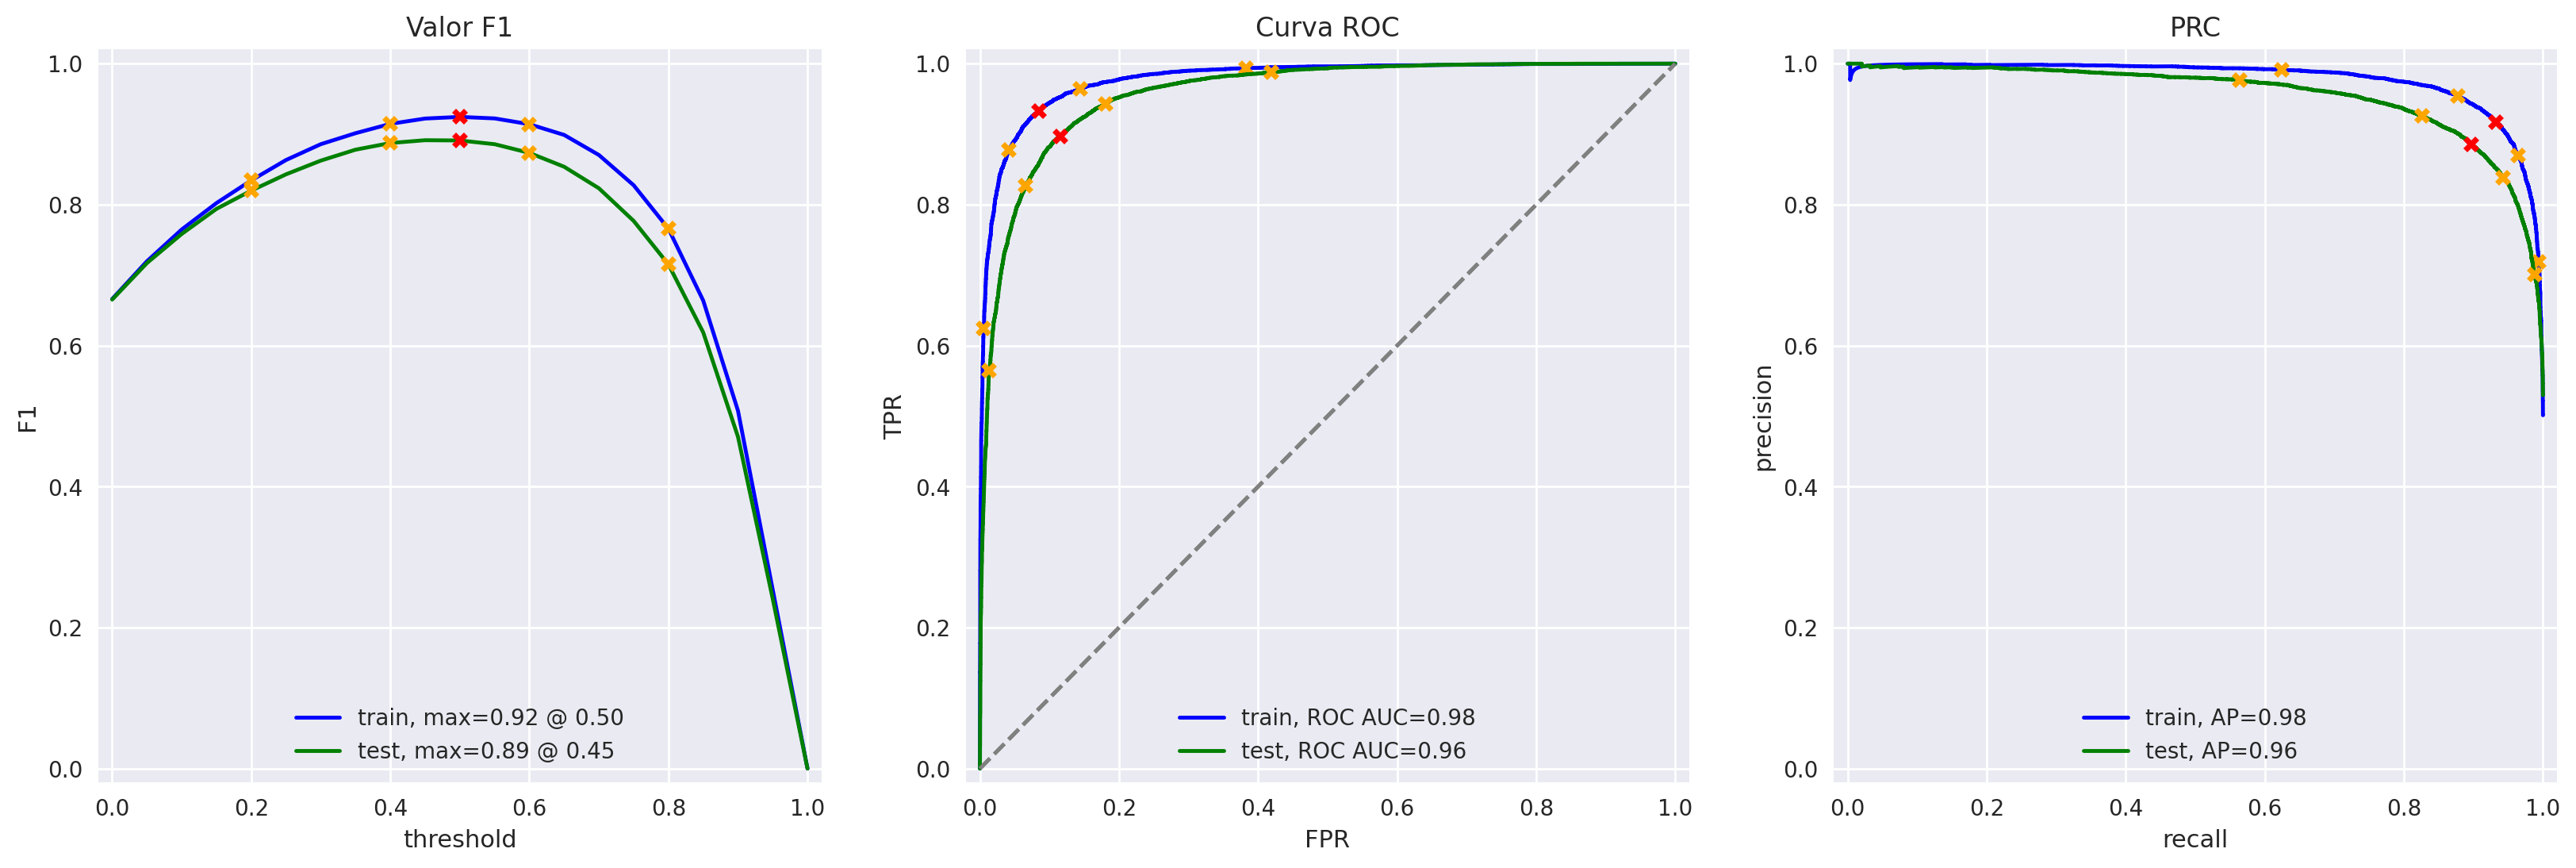

In [26]:
evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)

__O modelo 2__ alcançou um excelente desempenho, com __F1-score de 0,89 no conjunto de teste, superando a meta estabelecida de 0,85.__ As métricas de Acurácia, APS e ROC AUC também indicam forte capacidade discriminativa e boa generalização entre os dados de treino e teste. A análise das curvas de desempenho sugere que pequenos ajustes no limiar de decisão podem melhorar ainda mais os resultados, reforçando a robustez da metodologia adotada para a classificação de sentimentos em resenhas de filmes.

### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [37]:
from lightgbm import LGBMClassifier

In [36]:
# Definir o modelo LightGBM com parâmetros básicos
model_3 = LGBMClassifier(
    random_state=12345,
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    n_jobs=-1
)

# Treinar o modelo
model_3.fit(train_features_2, train_target)

LGBMClassifier(random_state=12345)

          train  test
Accuracy   0.93  0.87
F1         0.93  0.87
APS        0.98  0.94
ROC AUC    0.98  0.94


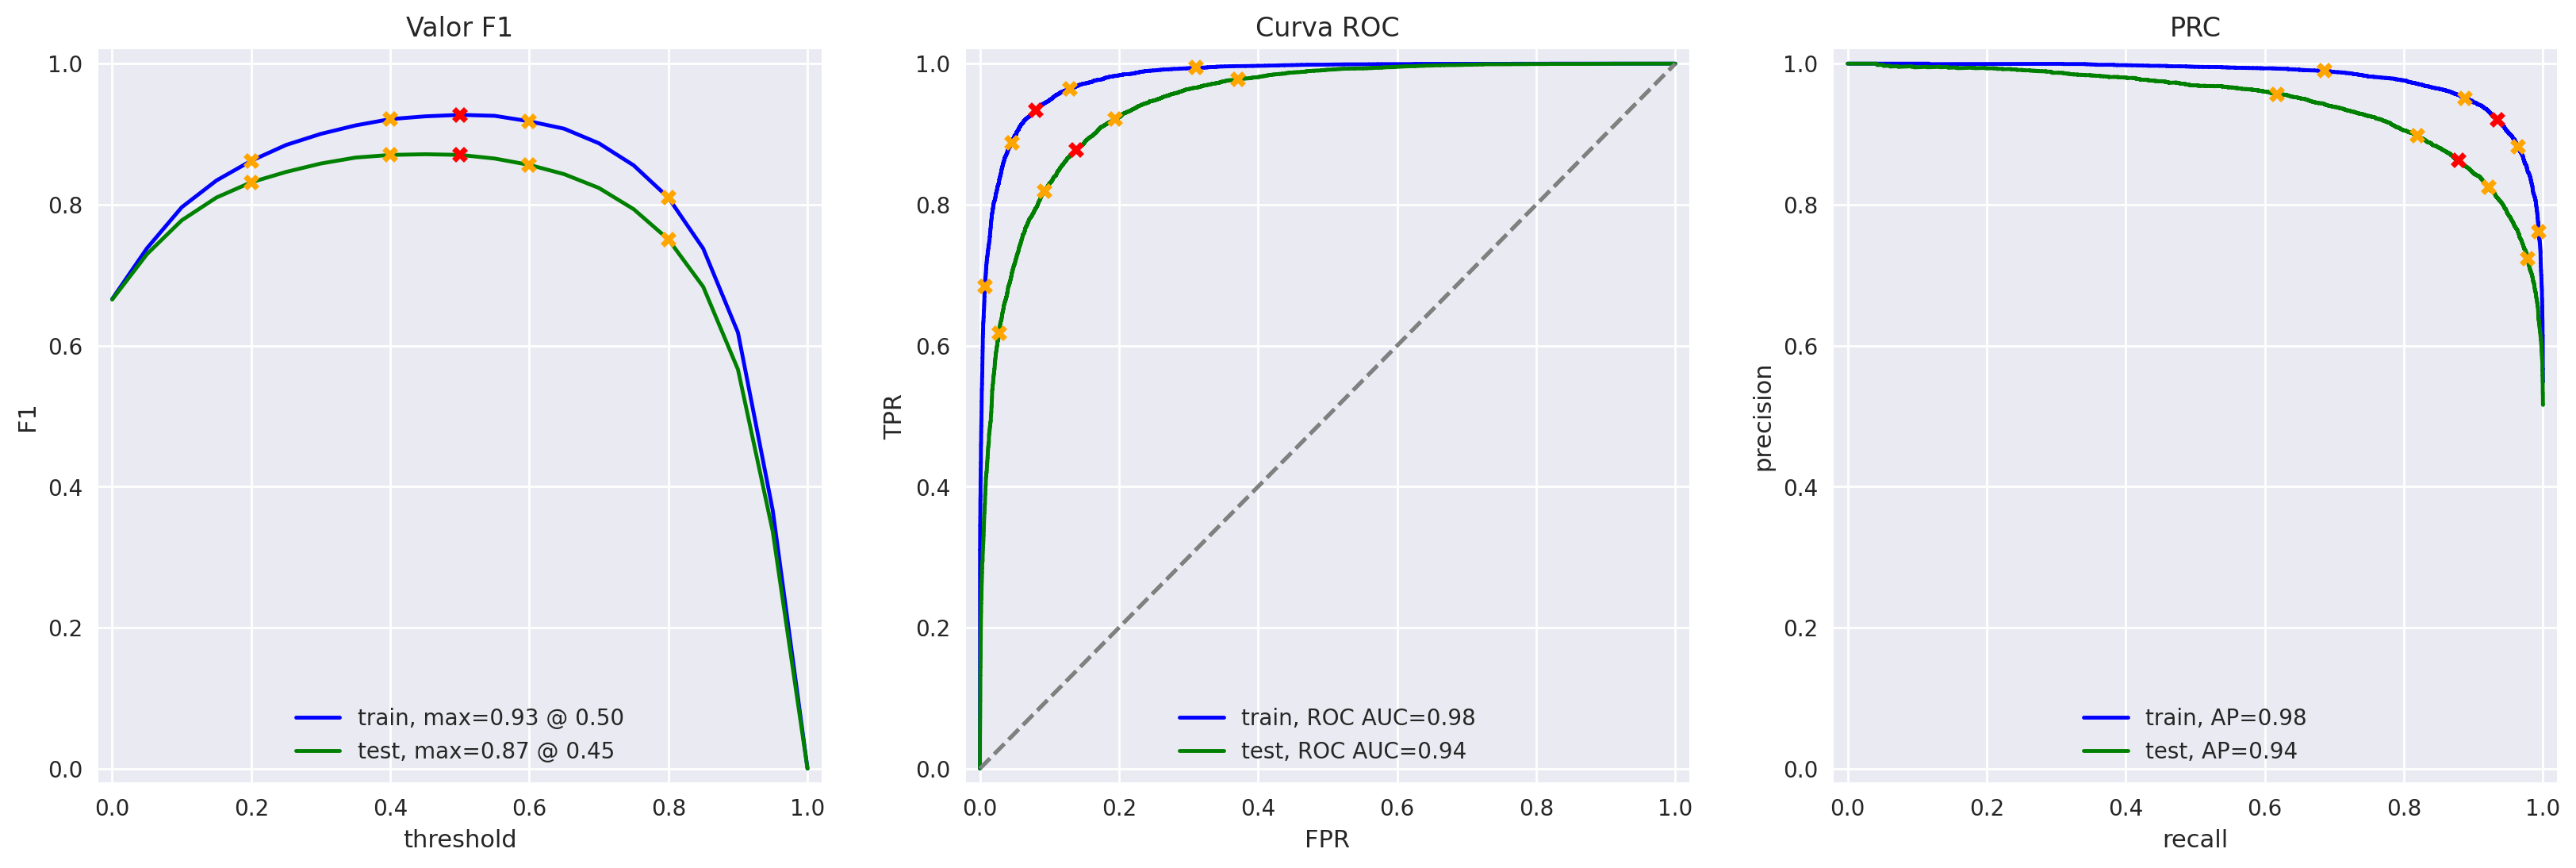

In [38]:
# Avaliar com sua função
evaluate_model(model_3, train_features_2, train_target, test_features_2, test_target)

__O modelo 4 apresentou excelente desempenho no conjunto de treino, com Acurácia e F1-score de 0,93, e manteve boa generalização no teste, com F1-score de 0,87.__ As métricas APS e ROC AUC também indicam forte capacidade discriminativa, mostrando que o modelo consegue estimar bem as probabilidades das classes. Comparado aos modelos anteriores (Regressão Logística), o LightGBM aumentou ligeiramente o desempenho no treino, mas manteve resultados consistentes no teste, sugerindo que ele capturou interações não lineares e padrões mais complexos do texto sem sofrer overfitting significativo. Esses resultados reforçam que métodos baseados em gradient boosting podem melhorar a classificação de sentimentos em resenhas de filmes, especialmente em tarefas de texto vetorizado.

###  Modelo 5 - BERT

In [39]:
import torch
import transformers

In [40]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [41]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # texto para IDs de tokens preenchidos com suas máscaras de atenção
    
    # <coloque seu código aqui para criar ids_list e attention_mask_list>
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # recebendo incorporações em lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <coloque seu código aqui para criar attention_mask_batch
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [43]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

__Como não consigo usar GPU nessa atividade, esse modelo foi excluido do escopo do Projeto.__

## Minhas Resenhas

In [45]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente não gostei, não é meu tipo de filme.',
    'Bem, eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei realmente fascinado com o filme',    
    'Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.',
    'Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após episódio, deste emocionante e inteligente novo drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].str.lower()
my_reviews['review_norm'] = my_reviews['review_norm'].str.replace(r'[^a-z\s]', '', regex=True)  # remove tudo que não for letra ou espaço
my_reviews['review_norm'] = my_reviews['review_norm'].str.strip()


my_reviews

,review,review_norm
0,"Eu simplesmente não gostei, não é meu tipo de ...",eu simplesmente no gostei no meu tipo de filme
1,"Bem, eu fiquei entediado e dormi no meio do fi...",bem eu fiquei entediado e dormi no meio do filme
2,Eu fiquei realmente fascinado com o filme,eu fiquei realmente fascinado com o filme
3,Os atores pareciam muito velhos e desinteressa...,os atores pareciam muito velhos e desinteressa...
4,Eu não esperava que a nova versão fosse tão bo...,eu no esperava que a nova verso fosse to boa o...
5,"O filme tem seus prós e contras, mas eu sinto ...",o filme tem seus prs e contras mas eu sinto qu...
6,Que tentativa podre de comédia. Nem uma única ...,que tentativa podre de comdia nem uma nica pia...
7,Lançar na Netflix foi uma jogada corajosa e eu...,lanar na netflix foi uma jogada corajosa e eu ...


### Modelo 1

In [51]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.67:  eu simplesmente no gostei no  meu tipo de filme
0.65:  bem eu fiquei entediado e dormi no meio do filme
0.50:  eu fiquei realmente fascinado com o filme
0.55:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.60:  eu no esperava que a nova verso fosse to boa os escritores realmente se importaram com o material or
0.52:  o filme tem seus prs e contras mas eu sinto que em geral  um filme decente eu posso me imaginar indo
0.68:  que tentativa podre de comdia nem uma nica piada cai todo mundo age de forma irritante e barulhenta 
0.49:  lanar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episdio aps ep


### Modelo 2

In [52]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tfidf_2.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.06:  eu simplesmente no gostei no  meu tipo de filme
0.01:  bem eu fiquei entediado e dormi no meio do filme
0.70:  eu fiquei realmente fascinado com o filme
0.37:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.11:  eu no esperava que a nova verso fosse to boa os escritores realmente se importaram com o material or
0.55:  o filme tem seus prs e contras mas eu sinto que em geral  um filme decente eu posso me imaginar indo
0.35:  que tentativa podre de comdia nem uma nica piada cai todo mundo age de forma irritante e barulhenta 
0.57:  lanar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episdio aps ep


### Modelo 3

In [54]:
texts = my_reviews['review_norm']

tfidf_vectorizer_3 = tfidf_2
my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.52:  eu simplesmente no gostei no  meu tipo de filme
0.49:  bem eu fiquei entediado e dormi no meio do filme
0.71:  eu fiquei realmente fascinado com o filme
0.69:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.37:  eu no esperava que a nova verso fosse to boa os escritores realmente se importaram com o material or
0.71:  o filme tem seus prs e contras mas eu sinto que em geral  um filme decente eu posso me imaginar indo
0.52:  que tentativa podre de comdia nem uma nica piada cai todo mundo age de forma irritante e barulhenta 
0.71:  lanar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episdio aps ep


### Modelo 9

In [55]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

ValueError: need at least one array to concatenate

## Conclusões

### Comparação de previsões dos modelos em frases de exemplo

Para entender melhor o comportamento dos modelos, avaliamos suas previsões (`predict_proba`) em algumas frases selecionadas:

- **Modelo 1 (TF-IDF + Logistic Regression sobre texto cru)** tende a superestimar a positividade, especialmente em frases claramente negativas, mostrando limitações em capturar nuances do texto sem pré-processamento linguístico.  
- **Modelo 2 (spaCy + TF-IDF + Logistic Regression)** apresenta melhor sensibilidade à negatividade, graças à lematização e à remoção de ruído. Frases negativas foram corretamente identificadas, enquanto frases positivas também receberam probabilidades coerentes.  
- **Modelo 3 (LightGBM + TF-IDF)** se mostra mais agressivo ao identificar positividade. Ele reconhece claramente frases positivas, mas mantém certo nível de neutralidade para frases negativas. A capacidade de capturar padrões mais complexos do gradient boosting permite que algumas nuances passem a ser modeladas melhor do que no Modelo 1.

Em resumo, enquanto o Modelo 1 é mais ingênuo e Modelos 2 e 3 são mais refinados, cada modelo apresenta diferentes sensibilidades a frases positivas e negativas, o que pode ser útil dependendo do objetivo da aplicação (por exemplo, priorizar detecção de críticas negativas ou manter sensibilidade geral ao sentimento).